# Using Dask to assess landcover

<style>
.scibtn {
  background-color: #04AA6D;
  color: white;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}
.techbtn {
  background-color: #0407aaff;
  color: white;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}
.databtn {
  background-color: #edfd03ff;
  color: black;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}

</style>

<button class="techbtn">Technical</button> 

__Description & purpose__: This notebook introduces *dask* and how it can be used on the Hub to process some larger jobs. As a demonstrator we will calculate the modal landcover class per pixel over a decade of landcover data from the European Space Agency (ESA). The data collection on EODH that we will use is the ESA Land Cover Climate Change Initiative (CCI): Global Land Cover Maps. Much of the workflow is expressed as lazy Dask graphs and are only computed when `.compute()` is called. Although this example is simple, it demonstrates how Dask can parallelise across CPU cores or a distributed cluster with zero code changes.

First we need to set up our Jupyter environment.

In [ ]:
# Run this cell if pyeodh is not installed, or needs updating
%pip install --upgrade pyeodh
%pip install rioxarray xarray numpy pandas pystac matplotlib

In [2]:
# Import packages
import os
import warnings

import pyeodh
import pystac
import urllib.request

import numpy as np
import pandas as pd
import xarray as xr
import dask
import dask.array as da
import matplotlib.pyplot as plt
import rioxarray

%matplotlib inline
warnings.filterwarnings("ignore", category=UserWarning)

This notebook is written and constructed in a way that is modular. Some of the inputs can be configured in the next cell. The main processing steps are then presented as a series of functions - those functions can be easily changed, run per cell or chained together and run in a final cell.

In [3]:
# CONFIGURATION

START_YEAR = 2006
END_YEAR   = 2015   # inclusive 

DATETIME_RANGE = f"{START_YEAR}-01-01T00:00:00Z/{END_YEAR}-12-31T23:59:59Z"

# Bounding box e.g. mainland Britain in EPSG:4326 [west, south, east, north]
# (lon_min, lat_min, lon_max, lat_max) can be defined using https://geojson.io/

# Area around Oxford
BBOX = [-1.4724114697858113, 51.606628996417555, -1.0989795612960052, 51.84678057888078]

COLLECTION_ID = "land_cover"   # ESA Land Cover Climate Change Initiative (CCI): Global Land Cover Maps

## Find the data

First we search EODH using `pyeodh` for the ESA Land Cover data.

In [5]:
# Find the landcover items on EODH

def search_landcover_items(collection = COLLECTION_ID, bbox = BBOX, datetime_range = DATETIME_RANGE):
    """
    Use pyeodh to search the EODH STAC catalogue and return a list of
    item objects matching the query.
    """

    client = pyeodh.Client(
        base_url="https://eodatahub.org.uk"
    ).get_catalog_service()
    
    print(f" Searching collection '{collection}' …")
    print(f" bbox          : {bbox}")
    print(f" datetime range: {datetime_range}")

    # get the items
    items = client.search(
        collections=[collection],
        bbox=bbox,
        datetime=datetime_range,
    )

    # Count the number of items returned by the search 
    total_items = sum(1 for _ in items)
    print(f"Total items: {total_items}")

    return items

items = search_landcover_items()

 Searching collection 'land_cover' …
 bbox          : [-1.4724114697858113, 51.606628996417555, -1.0989795612960052, 51.84678057888078]
 datetime range: 2006-01-01T00:00:00Z/2015-12-31T23:59:59Z
Total items: 10


In [6]:
# Get details about the items

def inspect_items(items):
    """
    Print a summary of STAC items with one row per item.
    """
    rows = []
    for item in items:
        dt = item.datetime
        assets = list(item.assets.keys())
        rows.append({
            "id":       item.id,
            "datetime": dt,
            "assets":   ", ".join(assets),
        })

    df = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)
    print("STAC item summary:")
    print(df.to_string(index=False))
    print()
    return df

summary = inspect_items(items)

# Determine which asset to load
asset_key = 'GeoTIFF'

STAC item summary:
                                        id                  datetime          assets
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2006-v2.0.7 2006-07-02 00:00:00+00:00 NetCDF, GeoTIFF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2007-v2.0.7 2007-07-02 00:00:00+00:00 GeoTIFF, NetCDF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2008-v2.0.7 2008-07-01 12:00:00+00:00 GeoTIFF, NetCDF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2009-v2.0.7 2009-07-02 00:00:00+00:00 GeoTIFF, NetCDF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2010-v2.0.7 2010-07-02 00:00:00+00:00 GeoTIFF, NetCDF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2011-v2.0.7 2011-07-02 00:00:00+00:00 GeoTIFF, NetCDF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2012-v2.0.7 2012-07-01 12:00:00+00:00 NetCDF, GeoTIFF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2013-v2.0.7 2013-07-02 00:00:00+00:00 GeoTIFF, NetCDF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2014-v2.0.7 2014-07-02 00:00:00+00:00 NetCDF, GeoTIFF
ESACCI-LC-L4-LCCS-Map-300m-P1Y-2015-v2.0.7 2015-07-02 00:00:00+00:00 NetCDF, GeoTIFF




<style>
.howbtn {
  background-color: #f7871fff;
  color: white;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}
</style>

<button class="howbtn">How-to Highlight</button>

Take the paginated responses and extract the information we want to create a list.

In [7]:
def to_pystac_items(items):
    pystac_items = []
    for item in items:
        raw = item.to_dict() # dict with 'type', 'geometry', 'properties', 'assets', etc.
        pystac_item = pystac.Item.from_dict(raw)
        pystac_items.append(pystac_item)

    # Sort chronologically so the time axis is ordered
    pystac_items.sort(key=lambda i: i.datetime or i.properties.get("datetime", ""))
    return pystac_items
a = to_pystac_items(items)

In [8]:
# check that the first three items have the info we need
for item in a[:3]:
        print(f"\n Item: {item.id}  |  datetime: {item.datetime}")
        print(f"  {'Asset key':<20} {'media_type':<20} {'href[:60]'}")
        print(f"  {'-'*20} {'-'*20} {'-'*60}")
        for key, asset in item.assets.items():
            print(f"  {key:<20} {str(asset.media_type):<20} {asset.href[:60]}")


 Item: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2006-v2.0.7  |  datetime: 2006-07-02 00:00:00+00:00
  Asset key            media_type           href[:60]
  -------------------- -------------------- ------------------------------------------------------------
  NetCDF               None                 https://dap.ceda.ac.uk/neodc/esacci/land_cover/data/land_cov
  GeoTIFF              None                 https://dap.ceda.ac.uk/neodc/esacci/land_cover/data/land_cov

 Item: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2007-v2.0.7  |  datetime: 2007-07-02 00:00:00+00:00
  Asset key            media_type           href[:60]
  -------------------- -------------------- ------------------------------------------------------------
  GeoTIFF              None                 https://dap.ceda.ac.uk/neodc/esacci/land_cover/data/land_cov
  NetCDF               None                 https://dap.ceda.ac.uk/neodc/esacci/land_cover/data/land_cov

 Item: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2008-v2.0.7  |  datetime: 2008-07-01 12:0

## Build a data cube

The following section sets up a data cube of just the area of interest.

In [9]:
# Extract one URL per item (defaults to GeoTIFF)
pystac_items = a

def get_asset_url(item) -> tuple[str, str]:
    """Return (url, format) preferring GeoTIFF over NetCDF."""
    assets = item.assets
    for key in ("GeoTIFF", "geotiff", "data", "classification", "lcm"):
        if key in assets:
            return assets[key].href, "tiff"
    for key in ("NetCDF", "netcdf", "nc"):
        if key in assets:
            return assets[key].href, "netcdf"
    # fallback: first asset
    first = next(iter(assets.values()))
    return first.href, "unknown"

In [10]:
# Open a single item. This is used as input for the cube.

def open_item(item, override_path):
    """
    Open one STAC item as a lazy (Dask-backed) 2-D DataArray (y, x).
    """
    if override_path:
        url = override_path
        fmt = "netcdf" if override_path.endswith(".nc") else "tiff"
    else:
        url, fmt = get_asset_url(item)
    
    print(f"  Opening [{fmt}] {item.id}  →  {url[:80]}")

    if fmt == "tiff":
        da_item = xr.open_dataarray(
            url,
            engine="rasterio",
            chunks={"x": 512, "y": 512},   # lazy Dask chunks
            mask_and_scale=False,          # keep raw integer class labels
        )

        if "band" in da_item.dims:
            da_item = da_item.squeeze("band", drop=True)

    else:
        # NetCDF: open the first data variable that looks like landcover
        ds = xr.open_dataset(
            url,
            engine="netcdf4",
            chunks={"lat": 512, "lon": 512},
            mask_and_scale=False,
        )

        lc_var = next(
            (v for v in ds.data_vars
             if any(k in v.lower() for k in ("lccs", "lc_class", "class", "land"))),
            list(ds.data_vars)[0],          # fallback: first variable
        )
        print(f"    Using variable: '{lc_var}'")
        da_item = ds[lc_var]
        # Normalise spatial dim names to y/x
        rename = {}
        if "lat" in da_item.dims:  rename["lat"] = "y"
        if "lon" in da_item.dims:  rename["lon"] = "x"
        if rename:
            da_item = da_item.rename(rename)
        # Drop any singleton time dim already present in the file
        if "time" in da_item.dims:
            da_item = da_item.squeeze("time", drop=True)

    # Tag with this item's datetime so concat builds a proper time axis
    da_item = da_item.assign_coords(time=item.datetime).expand_dims("time")
    return da_item

In [11]:
def download_items(pystac_items, out_dir="./lc_data"):
    '''
        Download dataset locally - only run as a back up and if the dataset is small 
        e.g. we have 10 landcover items
    '''
    os.makedirs(out_dir, exist_ok=True)
    local_paths = []
    for item in pystac_items:
        url, fmt = get_asset_url(item)
        ext = "nc" if fmt == "netcdf" else "tif"
        local_path = os.path.join(out_dir, f"{item.id}.{ext}")
        if not os.path.exists(local_path):
            print(f"Downloading {item.id} …")
            urllib.request.urlretrieve(url, local_path)
        else:
            print(f"  Already cached: {item.id}.{ext}")
        local_paths.append(local_path)
    return local_paths


def build_cube(pystac_items, local_paths):
    '''
        Build the data cube from all of the data
    '''
    print(f"\n Opening {len(pystac_items)} items lazily …")
    
    if local_paths:
        # Use local files — no network I/O during Dask compute
        slices = [open_item(item, override_path=path) 
                  for item, path in zip(pystac_items, local_paths)]
    else:
        # Read direct from remote URLs
        slices = [open_item(item) for item in pystac_items]

    print("\n Concatenating along time axis …")
    cube = xr.concat(slices, dim="time").sortby("time")
    cube = cube.rename("landcover")
    print(f"      Cube shape : {dict(cube.sizes)}")
    print(f"      Time range : {cube.time.values[0]}  →  {cube.time.values[-1]}")
    print(f"      Dask chunks: {cube.chunks}")
    return cube

In [12]:
# only run on manageable datasets
local_paths = download_items(pystac_items, out_dir="./lc_data")

  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2006-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2007-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2008-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2009-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2010-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2011-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2012-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2013-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2014-v2.0.7.tif
  Already cached: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2015-v2.0.7.tif


In [13]:
#Build the actual data cube
cube = build_cube(pystac_items, local_paths=local_paths)


 Opening 10 items lazily …
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2006-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2006-v2.0.7.tif
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2007-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2007-v2.0.7.tif
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2008-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2008-v2.0.7.tif
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2009-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2009-v2.0.7.tif
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2010-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2010-v2.0.7.tif
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2011-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2011-v2.0.7.tif
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2012-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2012-v2.0.7.tif
  Opening [tiff] ESACCI-LC-L4-LCCS-Map-300m-P1Y-2013-v2.0.7  →  ./lc_data/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2013-v2.0.7.tif
  Op

In [14]:
cube

<xarray.DataArray 'landcover' (time: 10, y: 64800, x: 129600)> Size: 84GB
dask.array<getitem, shape=(10, 64800, 129600), dtype=uint8, chunksize=(1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * y            (y) float64 518kB 90.0 90.0 89.99 89.99 ... -89.99 -90.0 -90.0
    spatial_ref  int64 8B 0
  * time         (time) object 80B 1151798400000000000 ... 1435795200000000000
Attributes:
    Copyright:       ESA 2017 - UCLouvain
    Dataset:         Global annual land cover map at 300 m based on the full ...
    Description:     Pixel value corresponds to the label of a land cover cla...
    Scaling Factor:  none
    Version:         2.0.7
    AREA_OR_POINT:   Area
    _FillValue:      0
    scale_factor:    1.0
    add_offset:      0.0

In [15]:
# Clip to the bounding box

xdsc = cube.rio.clip_box(
    minx=BBOX[0],
    miny=BBOX[1],
    maxx=BBOX[2],
    maxy=BBOX[3],
)
xdsc

<xarray.DataArray 'landcover' (time: 10, y: 87, x: 136)> Size: 118kB
dask.array<getitem, shape=(10, 87, 136), dtype=uint8, chunksize=(1, 87, 136), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 1kB -1.474 -1.471 -1.468 ... -1.104 -1.101 -1.099
  * y            (y) float64 696B 51.85 51.84 51.84 51.84 ... 51.61 51.61 51.61
  * time         (time) object 80B 1151798400000000000 ... 1435795200000000000
    spatial_ref  int64 8B 0
Attributes:
    Copyright:       ESA 2017 - UCLouvain
    Dataset:         Global annual land cover map at 300 m based on the full ...
    Description:     Pixel value corresponds to the label of a land cover cla...
    Scaling Factor:  none
    Version:         2.0.7
    AREA_OR_POINT:   Area
    scale_factor:    1.0
    add_offset:      0.0
    _FillValue:      0

## Analysis

Now that the data is in a format that can be used to calculate the land cover mode, we can use the dask `.compute` function. 

In [16]:

# Compute dominant (modal) class per pixel

def dominant_class(cube):
    """
    For each pixel, find which landcover class appears most often
    across all years (modal value over the time axis).

    Uses Dask to compute class counts in parallel — one pass per class label.
    For ESA CCI the LCCS class values are multi-digit integers (e.g. 10, 30,
    190 …)
    """
    print("\n Computing dominant class …")

    # Sample a spatial tile to discover class labels without loading everything
    sample = cube.isel(
        y=slice(0, 200), x=slice(0, 200)
    ).compute()
    unique_classes = np.unique(sample.values)
    unique_classes = unique_classes[unique_classes > 0]   # drop nodata (0 / fill)
    
    print(f" Detected {len(unique_classes)} unique classes: {unique_classes}")

    # For each class build a (y, x) count array — all lazy Dask ops
    count_arrays = []
    for cls in unique_classes:
        count = da.sum(cube.data == int(cls), axis=0)   # sum over time axis
        count_arrays.append(count)

    # Stack to (n_classes, y, x) then argmax → index of winning class
    counts_stack = da.stack(count_arrays, axis=0)       # lazy
    argmax_idx   = da.argmax(counts_stack, axis=0)      # lazy (y, x) of ints

    # ── Trigger computation ──────────────────────────────────────────────
    # Compute argmax_idx as a plain numpy array first, then use it to look up
    # class labels via standard numpy indexing.

    print(" Triggering Dask compute …")
    
    with dask.config.set(scheduler="threads"):
        argmax_np = argmax_idx.compute()                

    # Map argmax indices to class label values using numpy
    dominant_np = unique_classes[argmax_np]

    result = xr.DataArray(
        dominant_np,
        dims=["y", "x"],
        coords={"y": cube.coords["y"], "x": cube.coords["x"]},
        attrs={"long_name": "Dominant landcover class (mode over time)"},
    )

    result = xr.DataArray(
        dominant_np,
        dims=["y", "x"],
        coords={"y": cube.coords["y"], "x": cube.coords["x"]},
        attrs={"long_name": "Dominant landcover class (mode over time)"},
    )

    print("Complete")
    return result, unique_classes
    
dominant, classes = dominant_class(xdsc)


 Computing dominant class …
 Detected 13 unique classes: [ 10  11  30  40  60  70 100 110 130 180 190 200 210]
 Triggering Dask compute …
Complete


## Output summary

Finally, we pull out the statistics and also create a map of the dominant class for each pixel and a plot of class share.


 Dominant class frequency table:
 class_id  pixel_count   pct
       11         6990 59.08
      130         2211 18.69
      190         1159  9.80
       40          478  4.04
       30          351  2.97
       60          295  2.49
      210          119  1.01
      100           76  0.64
       10           48  0.41
      110           39  0.33
       70           29  0.25
      180           27  0.23
      200           10  0.08


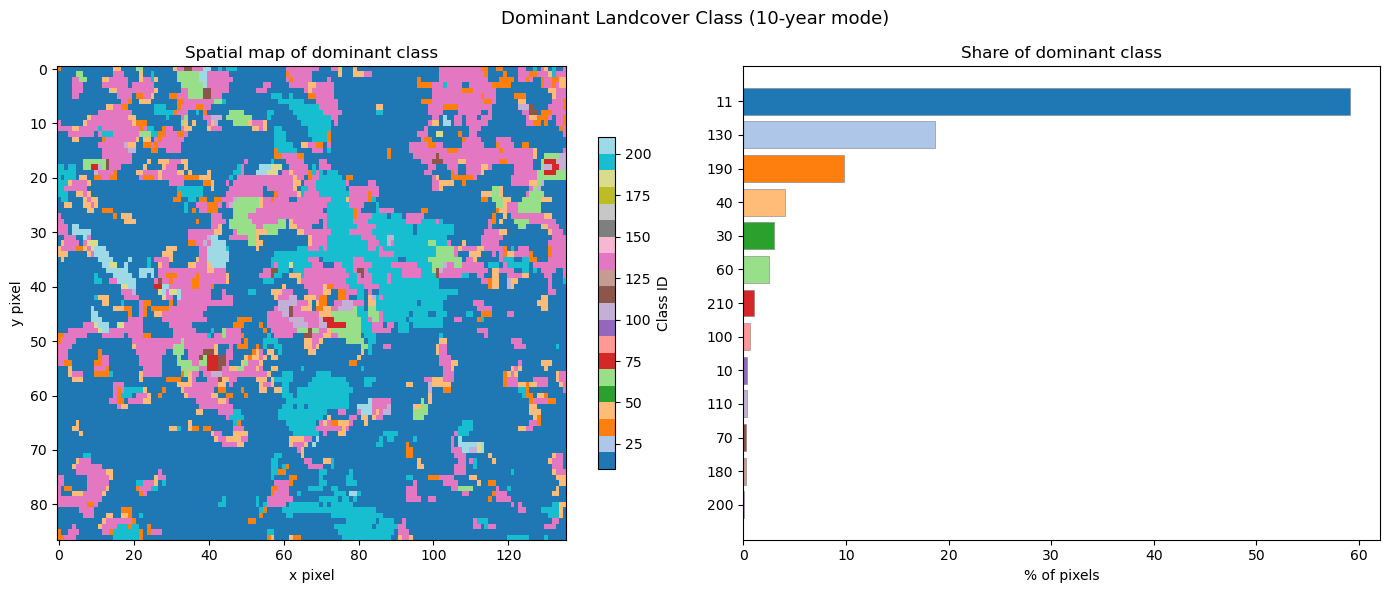

In [17]:
# Summarise and plot

def summarise_and_plot(dominant, unique_classes):

    vals = dominant.values.ravel()
    counts = {int(cls): int(np.sum(vals == cls)) for cls in unique_classes}
    total = sum(counts.values())

    df = pd.DataFrame([
        {"class_id": k, "pixel_count": v, "pct": round(100 * v / total, 2)}
        for k, v in sorted(counts.items(), key=lambda x: -x[1])
        if v > 0
    ])

    print("\n Dominant class frequency table:")
    print(df.to_string(index=False))

    # Generate plot
    fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Dominant Landcover Class (10-year mode)", fontsize=13)

    # Map
    #n_classes = len(df)
    cmap = plt.colormaps.get_cmap("tab20")  
    im = ax_map.imshow(
        dominant.values,
        cmap=cmap,
        interpolation="nearest",
        aspect="auto",
    )
    plt.colorbar(im, ax=ax_map, label="Class ID", shrink=0.7)
    ax_map.set_title("Spatial map of dominant class")
    ax_map.set_xlabel("x pixel")
    ax_map.set_ylabel("y pixel")

    # Bar chart
    ax_bar.barh(
        df["class_id"].astype(str),
        df["pct"],
        color=[cmap(i) for i in range(len(df))],
        edgecolor="grey", linewidth=0.4,
    )
    ax_bar.set_xlabel("% of pixels")
    ax_bar.set_title("Share of dominant class")
    ax_bar.invert_yaxis()

    plt.tight_layout()
    plt.show()

summarise_and_plot(dominant, classes)


---

__Author(s)__: Alastair Graham

__Date created__: 2026-03-16

__Date last modified__: 2026-03-16

__Licence__: This notebook is licensed under Creative Commons Attribution-ShareAlike 4.0 International. The code is released using the BSD-2-Clause license.

<span style="font-size:0.65em;">
Copyright &copy; - All rights reserved.

Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met:

Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer. Redistributions in binary form must reproduce the above copyright notice, this list of conditions and the following disclaimer in the documentation and/or other materials provided with the distribution. THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS “AS IS” AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.</span>
